<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/posterior_marginals_for_normal_gamma_case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


HOW MARGINALS ARE CALCULATED
Joint Posterior: p(μ,λ|X) = N(μ|μ_N, (β_Nλ)⁻¹) × Gam(λ|a_N,b_N)
  μ_N = 2.0, β_N = 5, a_N = 3, b_N = 4

1. MARGINAL FOR λ:
   p(λ|X) = ∫ p(μ,λ|X) dμ
          = Gam(λ|a_N,b_N) × ∫ N(μ|μ_N, (β_Nλ)⁻¹) dμ
          = Gam(λ|a_N,b_N) × 1
          = Gam(λ|a_N,b_N)

2. MARGINAL FOR μ:
   p(μ|X) = ∫ p(μ,λ|X) dλ
          = ∫ N(μ|μ_N, (β_Nλ)⁻¹) × Gam(λ|a_N,b_N) dλ
          = Student-t(μ | μ_N, β_Na_N/b_N, 2a_N)

3. WHY STUDENT-T?
   - Gaussian with random precision → heavier tails
   - Accounts for uncertainty in variance estimation
   - As a_N → ∞, Student-t → Gaussian


/tmp/ipython-input-1093879616.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  marginal_mu[i] = np.trapz(integrand, lambda_vals)


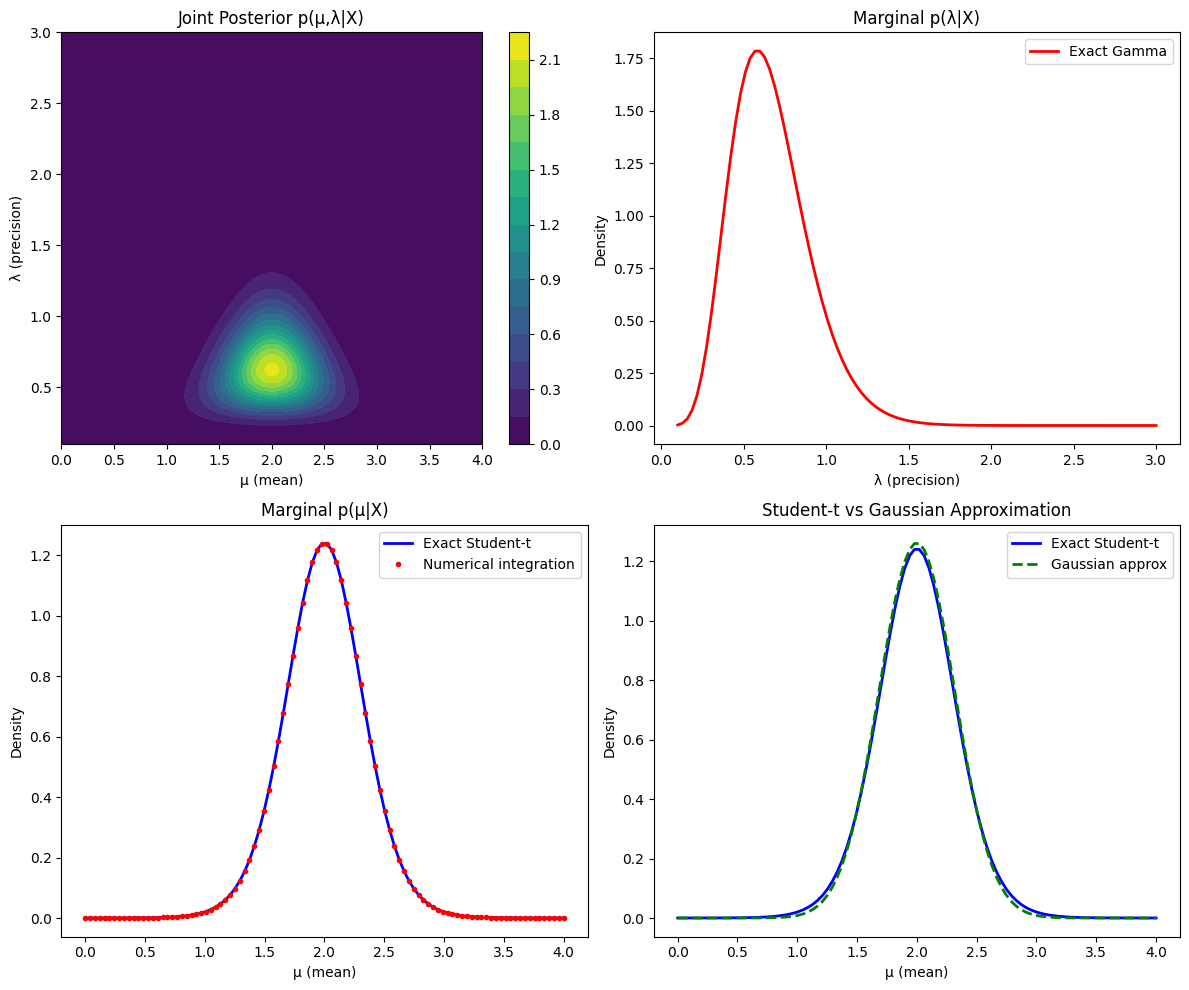

=== POSTERIOR MARGINAL STATISTICS ===
Marginal for λ: Gam(λ|a_N=8, b_N=12)
  E[λ] = 0.667
  Var[λ] = 0.056
  Std[λ] = 0.236

Marginal for μ: Student-t(μ|μ_N=2.0, ν=16.0)
  E[μ] = 2.000
  Mode[μ] = 2.000
  Var[μ] = 0.114 (for ν > 2)

Key insight: p(μ|X) has heavier tails than Gaussian!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, gamma, norm
import seaborn as sns

class PosteriorMarginals:
    """
    Demonstrate posterior marginals for Normal-Gamma case
    """

    def __init__(self, mu_N, beta_N, a_N, b_N):
        self.mu_N = mu_N
        self.beta_N = beta_N
        self.a_N = a_N
        self.b_N = b_N

    def joint_posterior(self, mu_vals, lambda_vals):
        """Joint posterior p(μ,λ|X)"""
        joint = np.zeros((len(mu_vals), len(lambda_vals)))

        for i, mu in enumerate(mu_vals):
            for j, lam in enumerate(lambda_vals):
                # Gaussian for μ given λ
                gaussian = norm.pdf(mu, self.mu_N, 1/np.sqrt(self.beta_N * lam))
                # Gamma for λ
                gamma_dist = gamma.pdf(lam, self.a_N, scale=1/self.b_N)
                joint[i,j] = gaussian * gamma_dist

        return joint

    def marginal_lambda(self, lambda_vals):
        """Marginal p(λ|X) = Gam(λ|a_N, b_N)"""
        return gamma.pdf(lambda_vals, self.a_N, scale=1/self.b_N)

    def marginal_mu_exact(self, mu_vals):
        """Exact marginal p(μ|X) using Student's t-distribution"""
        # Parameters for Student's t-distribution
        df = 2 * self.a_N  # degrees of freedom
        scale = np.sqrt(self.b_N / (self.beta_N * self.a_N))  # scale parameter

        return t.pdf(mu_vals, df, loc=self.mu_N, scale=scale)

    def marginal_mu_numerical(self, mu_vals, lambda_vals):
        """Numerical integration to get p(μ|X)"""
        marginal_mu = np.zeros_like(mu_vals)

        for i, mu in enumerate(mu_vals):
            # For fixed μ, integrate over λ
            integrand = np.zeros_like(lambda_vals)
            for j, lam in enumerate(lambda_vals):
                gaussian = norm.pdf(mu, self.mu_N, 1/np.sqrt(self.beta_N * lam))
                gamma_dist = gamma.pdf(lam, self.a_N, scale=1/self.b_N)
                integrand[j] = gaussian * gamma_dist

            # Numerical integration (trapezoidal rule)
            marginal_mu[i] = np.trapz(integrand, lambda_vals)

        return marginal_mu

def demonstrate_marginals():
    """Show the posterior marginals in action"""

    # Posterior parameters (after seeing some data)
    mu_N = 2.0      # Posterior mean for μ
    beta_N = 15     # Posterior scaling for μ's precision
    a_N = 8         # Posterior shape for λ
    b_N = 12        # Posterior rate for λ

    marginals = PosteriorMarginals(mu_N, beta_N, a_N, b_N)

    # Create grids for plotting
    mu_vals = np.linspace(0, 4, 100)
    lambda_vals = np.linspace(0.1, 3, 100)

    # Compute distributions
    joint = marginals.joint_posterior(mu_vals, lambda_vals)
    marginal_lambda = marginals.marginal_lambda(lambda_vals)
    marginal_mu_exact = marginals.marginal_mu_exact(mu_vals)
    marginal_mu_numerical = marginals.marginal_mu_numerical(mu_vals, lambda_vals)

    # Plot everything
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Joint posterior
    im = axes[0,0].contourf(mu_vals, lambda_vals, joint.T, levels=20, cmap='viridis')
    axes[0,0].set_xlabel('μ (mean)')
    axes[0,0].set_ylabel('λ (precision)')
    axes[0,0].set_title('Joint Posterior p(μ,λ|X)')
    plt.colorbar(im, ax=axes[0,0])

    # 2. Marginal for λ
    axes[0,1].plot(lambda_vals, marginal_lambda, 'r-', linewidth=2, label='Exact Gamma')
    axes[0,1].set_xlabel('λ (precision)')
    axes[0,1].set_ylabel('Density')
    axes[0,1].set_title('Marginal p(λ|X)')
    axes[0,1].legend()

    # 3. Marginal for μ
    axes[1,0].plot(mu_vals, marginal_mu_exact, 'b-', linewidth=2, label='Exact Student-t')
    axes[1,0].plot(mu_vals, marginal_mu_numerical, 'ro', markersize=3, label='Numerical integration')
    axes[1,0].set_xlabel('μ (mean)')
    axes[1,0].set_ylabel('Density')
    axes[1,0].set_title('Marginal p(μ|X)')
    axes[1,0].legend()

    # 4. Compare with Gaussian approximation
    # For large a_N, Student-t ≈ Gaussian
    gaussian_approx = norm.pdf(mu_vals, mu_N, np.sqrt(b_N/(beta_N * a_N)))
    axes[1,1].plot(mu_vals, marginal_mu_exact, 'b-', linewidth=2, label='Exact Student-t')
    axes[1,1].plot(mu_vals, gaussian_approx, 'g--', linewidth=2, label='Gaussian approx')
    axes[1,1].set_xlabel('μ (mean)')
    axes[1,1].set_ylabel('Density')
    axes[1,1].set_title('Student-t vs Gaussian Approximation')
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()

    # Print key statistics
    print("=== POSTERIOR MARGINAL STATISTICS ===")
    print(f"Marginal for λ: Gam(λ|a_N={a_N}, b_N={b_N})")
    print(f"  E[λ] = {a_N/b_N:.3f}")
    print(f"  Var[λ] = {a_N/(b_N**2):.3f}")
    print(f"  Std[λ] = {np.sqrt(a_N)/(b_N):.3f}")

    print(f"\nMarginal for μ: Student-t(μ|μ_N={mu_N}, ν={2*a_N:.1f})")
    print(f"  E[μ] = {mu_N:.3f}")
    print(f"  Mode[μ] = {mu_N:.3f}")

    # Variance of Student-t distribution
    if 2*a_N > 2:
        mu_variance = (b_N / (beta_N * a_N)) * (2*a_N / (2*a_N - 2))
        print(f"  Var[μ] = {mu_variance:.3f} (for ν > 2)")

    print(f"\nKey insight: p(μ|X) has heavier tails than Gaussian!")

def show_marginal_calculation():
    """Show step-by-step how marginals are calculated"""

    print("\n" + "="*50)
    print("HOW MARGINALS ARE CALCULATED")
    print("="*50)

    # Simple example with small numbers
    mu_N, beta_N, a_N, b_N = 2.0, 5, 3, 4

    print("Joint Posterior: p(μ,λ|X) = N(μ|μ_N, (β_Nλ)⁻¹) × Gam(λ|a_N,b_N)")
    print(f"  μ_N = {mu_N}, β_N = {beta_N}, a_N = {a_N}, b_N = {b_N}")

    print("\n1. MARGINAL FOR λ:")
    print("   p(λ|X) = ∫ p(μ,λ|X) dμ")
    print("          = Gam(λ|a_N,b_N) × ∫ N(μ|μ_N, (β_Nλ)⁻¹) dμ")
    print("          = Gam(λ|a_N,b_N) × 1")
    print("          = Gam(λ|a_N,b_N)")

    print("\n2. MARGINAL FOR μ:")
    print("   p(μ|X) = ∫ p(μ,λ|X) dλ")
    print("          = ∫ N(μ|μ_N, (β_Nλ)⁻¹) × Gam(λ|a_N,b_N) dλ")
    print("          = Student-t(μ | μ_N, β_Na_N/b_N, 2a_N)")

    print("\n3. WHY STUDENT-T?")
    print("   - Gaussian with random precision → heavier tails")
    print("   - Accounts for uncertainty in variance estimation")
    print("   - As a_N → ∞, Student-t → Gaussian")

if __name__ == "__main__":
    show_marginal_calculation()
    demonstrate_marginals()